## 1. Setup and Imports

In [7]:
# ! pip install lime

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from lime.lime_text import LimeTextExplainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"✅ Libraries loaded successfully!")


c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\aweso\Documents\fakenews-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cuda
✅ Libraries loaded successfully!


## 2. Model Loading Configuration

In [8]:
# Define model paths - modify these to compare different models
MODEL_1_PATH = '../../models/bert_fake_news_trained_v2'          # Model 1 to compare
MODEL_1_NAME = 'Combined Specialist'

MODEL_2_PATH = '../../models/bert_politifact_retrained'       # Model 2 to compare
MODEL_2_NAME = 'Political Specialist'

# Results file configuration
RESULTS_FILE = 'playground_results.txt'

# You can also swap in the combined model:
# MODEL_2_PATH = '../../models/bert_fake_news_trained_v2'
# MODEL_2_NAME = 'Combined General'

print(f"📊 Model Configuration:")
print(f"  Model 1: {MODEL_1_NAME} ({MODEL_1_PATH})")
print(f"  Model 2: {MODEL_2_NAME} ({MODEL_2_PATH})")
print(f"  Results file: {RESULTS_FILE}")

📊 Model Configuration:
  Model 1: Combined Specialist (../../models/bert_fake_news_trained_v2)
  Model 2: Political Specialist (../../models/bert_politifact_retrained)
  Results file: playground_results.txt


## 3. Load Models

In [9]:
# Load Model 1
print(f"\n🔄 Loading {MODEL_1_NAME}...")
try:
    if 'model_1' not in locals() or model_1 is None:
        model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_1_PATH)
        tokenizer_1 = AutoTokenizer.from_pretrained(MODEL_1_PATH)
        model_1.to(device)
        model_1.eval()
        print(f"✅ {MODEL_1_NAME} loaded successfully!")
    else:
        print(f"✅ {MODEL_1_NAME} already loaded!")
except Exception as e:
    print(f"❌ Error: {e}")
    model_1 = None

# Load Model 2
print(f"\n🔄 Loading {MODEL_2_NAME}...")
try:
    if 'model_2' not in locals() or model_2 is None:
        model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_2_PATH)
        tokenizer_2 = AutoTokenizer.from_pretrained(MODEL_2_PATH)
        model_2.to(device)
        model_2.eval()
        print(f"✅ {MODEL_2_NAME} loaded successfully!")
    else:
        print(f"✅ {MODEL_2_NAME} already loaded!")
except Exception as e:
    print(f"❌ Error: {e}")
    model_2 = None

print(f"\n✅ Both models ready for comparison!")



🔄 Loading Combined Specialist...
✅ Combined Specialist loaded successfully!

🔄 Loading Political Specialist...
✅ Political Specialist loaded successfully!

✅ Both models ready for comparison!
✅ Combined Specialist loaded successfully!

🔄 Loading Political Specialist...
✅ Political Specialist loaded successfully!

✅ Both models ready for comparison!


## 4. Prediction Function

In [5]:
def predict_text(text, model, tokenizer, device):
    """Get prediction and confidence for a text sample"""
    if model is None:
        return None, None, None
    
    text = str(text).strip()
    if not text:
        return None, None, None
    
    try:
        inputs = tokenizer(
            text,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            prediction = torch.argmax(logits, dim=-1).item()
            fake_prob = probs[0][0].item()
            real_prob = probs[0][1].item()
        
        return prediction, {'fake': fake_prob, 'real': real_prob}, max(fake_prob, real_prob)
    except Exception as e:
        print(f"Error: {e}")
        return None, None, None

def save_results(test_article, pred_1, probs_1, conf_1, pred_2, probs_2, conf_2, model_1_name, model_2_name, results_file):
    """Save prediction results to a text file"""
    from datetime import datetime
    
    pred_1_label = 'REAL' if pred_1 == 1 else 'FAKE' if pred_1 == 0 else 'ERROR'
    pred_2_label = 'REAL' if pred_2 == 1 else 'FAKE' if pred_2 == 0 else 'ERROR'
    
    with open(results_file, 'a', encoding='utf-8') as f:
        f.write("\n" + "="*100 + "\n")
        # Count existing tests by counting = lines
        try:
            with open(results_file, 'r', encoding='utf-8') as rf:
                test_num = rf.read().count("="*100) // 2
        except:
            test_num = 0
        f.write(f"Test #{test_num}\n")
        f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*100 + "\n\n")
        
        # Article preview (first 300 chars)
        article_preview = test_article.strip()[:300] + "..." if len(test_article.strip()) > 300 else test_article.strip()
        f.write(f"ARTICLE TESTED:\n{article_preview}\n\n")
        
        # Model 1 results
        f.write(f"{'─'*100}\n")
        f.write(f"{model_1_name}:\n")
        f.write(f"  Prediction: {pred_1_label}\n")
        if probs_1:
            f.write(f"  Fake Probability: {probs_1['fake']:.4f} ({probs_1['fake']:.2%})\n")
            f.write(f"  Real Probability: {probs_1['real']:.4f} ({probs_1['real']:.2%})\n")
            f.write(f"  Confidence: {conf_1:.4f} ({conf_1:.2%})\n")
        f.write("\n")
        
        # Model 2 results
        f.write(f"{model_2_name}:\n")
        f.write(f"  Prediction: {pred_2_label}\n")
        if probs_2:
            f.write(f"  Fake Probability: {probs_2['fake']:.4f} ({probs_2['fake']:.2%})\n")
            f.write(f"  Real Probability: {probs_2['real']:.4f} ({probs_2['real']:.2%})\n")
            f.write(f"  Confidence: {conf_2:.4f} ({conf_2:.2%})\n")
        f.write("\n")
        
        # Agreement/Disagreement
        f.write(f"{'─'*100}\n")
        if pred_1 == pred_2:
            f.write(f"✅ Models AGREE: Both predict {pred_1_label}\n")
        else:
            f.write(f"⚠️  Models DISAGREE: {model_1_name} says {pred_1_label}, {model_2_name} says {pred_2_label}\n")
        f.write("\n")

print("✅ Prediction and logging functions ready")


✅ Prediction and logging functions ready


## 5. Setup LIME Explainers

In [10]:
def create_predictor(model, tokenizer, device):
    """Create prediction function for LIME"""
    def predict_fn(texts):
        predictions = []
        for text in texts:
            text = str(text) if isinstance(text, (list, tuple)) else text
            pred, probs, conf = predict_text(text, model, tokenizer, device)
            if probs:
                predictions.append([probs['fake'], probs['real']])
            else:
                predictions.append([0.5, 0.5])
        return np.array(predictions)
    return predict_fn

# Create LIME explainers
print("⚙️  Setting up LIME explainers...")
explainer_1 = LimeTextExplainer(class_names=['Fake News', 'Real News'])
explainer_2 = LimeTextExplainer(class_names=['Fake News', 'Real News'])

predictor_1 = create_predictor(model_1, tokenizer_1, device) if model_1 else None
predictor_2 = create_predictor(model_2, tokenizer_2, device) if model_2 else None

print("✅ LIME explainers ready")

⚙️  Setting up LIME explainers...
✅ LIME explainers ready


## 6. 🎮 PLAYGROUND: Test Your Article Here!

Replace the article below with any text you want to test. Both models will analyze it and show which words influence their predictions.

In [ ]:
# ===== LOAD POLITIFACT TEST DATA =====
import os
import pandas as pd

workspace_root = r'c:\Users\aweso\Documents\fakenews-analysis'
data_dir = os.path.join(workspace_root, 'data', 'processed', '00')
test_file = os.path.join(data_dir, 'politifact_test.csv')

print("Loading PolitiFact test data...")
test_df = pd.read_csv(test_file)
test_df = test_df.rename(columns={'news': 'Article', 'label': 'Truth'})
test_df = test_df[['Article', 'Truth']].copy()

print(f"\n✅ Loaded {len(test_df)} test articles")
print(f"\nClass distribution:")
print(test_df['Truth'].value_counts())

# ===== SELECT TEST ARTICLES FROM POLITIFACT TEST SET =====
# Pick a few examples to analyze in detail

# You can modify these indices to test different articles
test_indices = [0, 5, 10, 15]  # Pick 4 articles to analyze

print("\n" + "="*80)
print("📰 Test Articles from PolitiFact Test Set:")
print("="*80)

for idx in test_indices:
    if idx < len(test_df):
        article = test_df['Article'].iloc[idx]
        truth = test_df['Truth'].iloc[idx]
        label = 'REAL' if truth == 1 else 'FAKE'
        print(f"\nArticle #{idx} (Ground Truth: {label})")
        print("-" * 80)
        print(article[:300] + "..." if len(article) > 300 else article)
        print()

# For detailed analysis, we'll use the first article
test_index = 0
test_article = test_df['Article'].iloc[test_index]
ground_truth = test_df['Truth'].iloc[test_index]
ground_truth_label = 'REAL' if ground_truth == 1 else 'FAKE'

print("\n" + "="*80)
print(f"DETAILED ANALYSIS: Article #{test_index}")
print(f"Ground Truth: {ground_truth_label}")
print("="*80)
print(test_article)
print("="*80)


## 7. 🔮 Get Predictions from Both Models

In [ ]:
print(f"\n🔍 Analyzing test set with both models...\n")
print("="*80)

# Get predictions from Model 1
pred_1, probs_1, conf_1 = predict_text(test_article, model_1, tokenizer_1, device)
pred_1_label = 'REAL' if pred_1 == 1 else 'FAKE' if pred_1 == 0 else 'ERROR'

print(f"\n📊 {MODEL_1_NAME}:")
print(f"  Prediction: {pred_1_label}")
print(f"  Ground Truth: {ground_truth_label}")
print(f"  Match: {'✅ CORRECT' if pred_1 == ground_truth else '❌ WRONG'}")
if probs_1:
    print(f"  Fake Probability: {probs_1['fake']:.2%}")
    print(f"  Real Probability: {probs_1['real']:.2%}")
    print(f"  Confidence: {conf_1:.2%}")

# Get predictions from Model 2
pred_2, probs_2, conf_2 = predict_text(test_article, model_2, tokenizer_2, device)
pred_2_label = 'REAL' if pred_2 == 1 else 'FAKE' if pred_2 == 0 else 'ERROR'

print(f"\n📊 {MODEL_2_NAME}:")
print(f"  Prediction: {pred_2_label}")
print(f"  Ground Truth: {ground_truth_label}")
print(f"  Match: {'✅ CORRECT' if pred_2 == ground_truth else '❌ WRONG'}")
if probs_2:
    print(f"  Fake Probability: {probs_2['fake']:.2%}")
    print(f"  Real Probability: {probs_2['real']:.2%}")
    print(f"  Confidence: {conf_2:.2%}")

print("\n" + "="*80)

# Show agreement/disagreement
if pred_1 == pred_2:
    print(f"✅ Models AGREE: Both predict {pred_1_label}")
else:
    print(f"⚠️  Models DISAGREE: {MODEL_1_NAME} says {pred_1_label}, {MODEL_2_NAME} says {pred_2_label}")

# Save results to file
print(f"\n💾 Saving results to {RESULTS_FILE}...")
save_results(test_article, pred_1, probs_1, conf_1, pred_2, probs_2, conf_2, MODEL_1_NAME, MODEL_2_NAME, RESULTS_FILE)
print(f"✅ Results saved!")

# ===== EVALUATE ON FULL TEST SET =====
print(f"\n\n{'='*80}")
print("📊 EVALUATING ON FULL TEST SET")
print(f"{'='*80}")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Get predictions for all test articles
all_preds_1 = []
all_preds_2 = []
all_probs_1 = []
all_probs_2 = []
ground_truths = []

print(f"\nEvaluating {len(test_df)} articles...")
for idx, row in test_df.iterrows():
    article = row['Article']
    truth = row['Truth']
    
    pred_1, probs_1_i, _ = predict_text(article, model_1, tokenizer_1, device)
    pred_2, probs_2_i, _ = predict_text(article, model_2, tokenizer_2, device)
    
    all_preds_1.append(pred_1)
    all_preds_2.append(pred_2)
    if probs_1_i:
        all_probs_1.append(probs_1_i['real'])
    else:
        all_probs_1.append(0.5)
    if probs_2_i:
        all_probs_2.append(probs_2_i['real'])
    else:
        all_probs_2.append(0.5)
    ground_truths.append(truth)
    
    if (idx + 1) % 500 == 0:
        print(f"  Processed {idx + 1}/{len(test_df)} articles...")

print(f"✅ Evaluation complete!")

# Calculate metrics for Model 1
acc_1 = accuracy_score(ground_truths, all_preds_1)
prec_1 = precision_score(ground_truths, all_preds_1)
rec_1 = recall_score(ground_truths, all_preds_1)
f1_1 = f1_score(ground_truths, all_preds_1)
roc_1 = roc_auc_score(ground_truths, all_probs_1)
cm_1 = confusion_matrix(ground_truths, all_preds_1)

# Calculate metrics for Model 2
acc_2 = accuracy_score(ground_truths, all_preds_2)
prec_2 = precision_score(ground_truths, all_preds_2)
rec_2 = recall_score(ground_truths, all_preds_2)
f1_2 = f1_score(ground_truths, all_preds_2)
roc_2 = roc_auc_score(ground_truths, all_probs_2)
cm_2 = confusion_matrix(ground_truths, all_preds_2)

# Display results
print(f"\n\n{'='*80}")
print(f"MODEL COMPARISON: {MODEL_1_NAME} vs {MODEL_2_NAME}")
print(f"{'='*80}")

print(f"\n{MODEL_1_NAME}:")
print(f"  Accuracy:  {acc_1:.4f} ({acc_1:.2%})")
print(f"  Precision: {prec_1:.4f} ({prec_1:.2%})")
print(f"  Recall:    {rec_1:.4f} ({rec_1:.2%})")
print(f"  F1-Score:  {f1_1:.4f}")
print(f"  ROC-AUC:   {roc_1:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN={cm_1[0,0]:4d}  FP={cm_1[0,1]:4d}")
print(f"    FN={cm_1[1,0]:4d}  TP={cm_1[1,1]:4d}")

print(f"\n{MODEL_2_NAME}:")
print(f"  Accuracy:  {acc_2:.4f} ({acc_2:.2%})")
print(f"  Precision: {prec_2:.4f} ({prec_2:.2%})")
print(f"  Recall:    {rec_2:.4f} ({rec_2:.2%})")
print(f"  F1-Score:  {f1_2:.4f}")
print(f"  ROC-AUC:   {roc_2:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN={cm_2[0,0]:4d}  FP={cm_2[0,1]:4d}")
print(f"    FN={cm_2[1,0]:4d}  TP={cm_2[1,1]:4d}")

print(f"\n{'='*80}")


## 8. 🔬 LIME Analysis: Word Importance Weights
Enter your own article below to analyze which words most influence each model's prediction using LIME


In [7]:
# ===== INPUT YOUR ARTICLE HERE =====
# Replace the article_to_analyze below with any text you want to test
article_to_analyze = """
VATICAN CITY—In a milestone many Roman Catholics hope will bring the church into the 21st century, Vatican officials issued a statement Tuesday formally recognizing Generation Z's first demon. "For his innovative use of digital communications to torment and possess the Christian faithful, Melapheus, better known by his online handle DiabolusMel, is hereby accorded full demonhood," Pope Leo XIV wrote in an official decree announcing the decision, adding that countless young sinners had been inspired to lead lives of infernal debauchery thanks to the 23-year-old malevolent spirit's wretched example. "The church has verified and can attribute to him the demonic possession of a girl who was left in a coma after a car accident. Through the intercession of Melapheus, this child was awakened from her state of unconsciousness and forced to pick up a surgical scalpel, which she then used to carve out the hearts of several doctors and nurses. His live-streamed inflictions of strange maladies that defy scientific explanation have spread the unholy word of Lucifer to millions who might not have heard the vile blasphemy otherwise. Indeed, many in their late teens and 20s say it was Melapheus' terrible screeching emanating from their phones that first led them to seek out our church's exorcists." At press time, the Vatican confirmed that Melapheus was eligible to become an archdemon after a verified possession that gave a blind man the ability to see into the endless depths of hell.
"""

# OR uncomment below to use an article from the test set:
# article_to_analyze = test_df['Article'].iloc[0]  # Change 0 to any index

print(f"\n{'='*80}")
print(f"🔬 LIME ANALYSIS: Word Importance Weights")
print(f"{'='*80}")
print(f"\nArticle being analyzed:\n{article_to_analyze[:500]}...")

# Get predictions for the input article
pred_1_lime, probs_1_lime, conf_1_lime = predict_text(article_to_analyze, model_1, tokenizer_1, device)
pred_1_label_lime = 'REAL' if pred_1_lime == 1 else 'FAKE' if pred_1_lime == 0 else 'ERROR'

pred_2_lime, probs_2_lime, conf_2_lime = predict_text(article_to_analyze, model_2, tokenizer_2, device)
pred_2_label_lime = 'REAL' if pred_2_lime == 1 else 'FAKE' if pred_2_lime == 0 else 'ERROR'

print(f"\n{MODEL_1_NAME} Prediction: {pred_1_label_lime}")
if probs_1_lime:
    print(f"  Confidence: {conf_1_lime:.2%}")
print(f"\n{MODEL_2_NAME} Prediction: {pred_2_label_lime}")
if probs_2_lime:
    print(f"  Confidence: {conf_2_lime:.2%}")

# Run LIME explanations
print(f"\n⏳ Computing LIME explanations (this may take 30-60 seconds)...")

try:
    # LIME explanation for Model 1
    exp_1 = explainer_1.explain_instance(article_to_analyze, predictor_1, num_features=15, num_samples=1000)
    lime_weights_1 = exp_1.as_list()
    
    # LIME explanation for Model 2
    exp_2 = explainer_2.explain_instance(article_to_analyze, predictor_2, num_features=15, num_samples=1000)
    lime_weights_2 = exp_2.as_list()
    
    print(f"✅ LIME explanations complete!")
    
    # Display weights
    print(f"\n{'─'*80}")
    print(f"{MODEL_1_NAME} - Top Words Influencing Prediction (Class: {pred_1_label_lime})")
    print(f"{'─'*80}")
    print(f"{'Word':<25} {'Weight':>10} {'Impact':>10}")
    print(f"{'-'*45}")
    
    for word, weight in lime_weights_1:
        direction = pred_1_label_lime if weight > 0 else ('FAKE' if pred_1_label_lime == 'REAL' else 'REAL')
        print(f"{word:<25} {weight:>10.4f}  {direction:<10}")
    
    print(f"\n{'─'*80}")
    print(f"{MODEL_2_NAME} - Top Words Influencing Prediction (Class: {pred_2_label_lime})")
    print(f"{'─'*80}")
    print(f"{'Word':<25} {'Weight':>10} {'Impact':>10}")
    print(f"{'-'*45}")
    
    for word, weight in lime_weights_2:
        direction = pred_2_label_lime if weight > 0 else ('FAKE' if pred_2_label_lime == 'REAL' else 'REAL')
        print(f"{word:<25} {weight:>10.4f}  {direction:<10}")
    
    # Comparison
    print(f"\n{'='*80}")
    print(f"💡 INSIGHT: Model Comparison")
    print(f"{'='*80}")
    
    words_1 = set([word for word, _ in lime_weights_1])
    words_2 = set([word for word, _ in lime_weights_2])
    
    common_words = words_1.intersection(words_2)
    unique_to_1 = words_1 - words_2
    unique_to_2 = words_2 - words_1
    
    print(f"\n📊 Word Overlap:")
    print(f"  Common important words: {len(common_words)}")
    if common_words:
        print(f"    {', '.join(list(common_words)[:7])}")
    print(f"  Unique to {MODEL_1_NAME}: {len(unique_to_1)}")
    if unique_to_1:
        print(f"    {', '.join(list(unique_to_1)[:5])}")
    print(f"  Unique to {MODEL_2_NAME}: {len(unique_to_2)}")
    if unique_to_2:
        print(f"    {', '.join(list(unique_to_2)[:5])}")
    
    # ===== SEMANTIC ANALYSIS FOR PRESENTATION =====
    print(f"\n{'='*80}")
    print(f"📝 SEMANTIC ANALYSIS: Language Patterns & Presentation Insights")
    print(f"{'='*80}")
    
    # Semantic categories
    emotional_words = {'demonic', 'infernal', 'wretched', 'malevolent', 'terrible', 'screeching', 'blasphemy', 'torment', 'vile', 'debauchery'}
    sensational_words = {'unprecedented', 'shocking', 'milestone', 'historic', 'radical', 'innovative', 'extraordinary', 'remarkable'}
    vague_words = {'many', 'countless', 'some', 'several', 'strange', 'defy', 'unexplained', 'mysterious', 'unknown'}
    specific_words = {'verified', 'decree', 'statement', 'official', 'confirmed', 'specific', 'documented', 'evidence'}
    
    # Analyze Model 1 weights
    print(f"\n🔴 {MODEL_1_NAME} Analysis:")
    model_1_words = [word.lower() for word, _ in lime_weights_1]
    
    emotional_found_1 = [w for w in model_1_words if any(e in w for e in emotional_words)]
    sensational_found_1 = [w for w in model_1_words if any(s in w for s in sensational_words)]
    vague_found_1 = [w for w in model_1_words if any(v in w for v in vague_words)]
    specific_found_1 = [w for w in model_1_words if any(sp in w for sp in specific_words)]
    
    print(f"  Emotional Language Detected: {len(emotional_found_1)} words")
    if emotional_found_1:
        print(f"    → {', '.join(emotional_found_1[:3])}")
    
    print(f"  Sensational Markers: {len(sensational_found_1)} words")
    if sensational_found_1:
        print(f"    → {', '.join(sensational_found_1[:3])}")
    
    print(f"  Vague/Unsubstantiated Language: {len(vague_found_1)} words")
    if vague_found_1:
        print(f"    → {', '.join(vague_found_1[:3])}")
    
    print(f"  Specific/Factual Markers: {len(specific_found_1)} words")
    if specific_found_1:
        print(f"    → {', '.join(specific_found_1[:3])}")
    
    # Analyze Model 2 weights
    print(f"\n🔵 {MODEL_2_NAME} Analysis:")
    model_2_words = [word.lower() for word, _ in lime_weights_2]
    
    emotional_found_2 = [w for w in model_2_words if any(e in w for e in emotional_words)]
    sensational_found_2 = [w for w in model_2_words if any(s in w for s in sensational_words)]
    vague_found_2 = [w for w in model_2_words if any(v in w for v in vague_words)]
    specific_found_2 = [w for w in model_2_words if any(sp in w for sp in specific_words)]
    
    print(f"  Emotional Language Detected: {len(emotional_found_2)} words")
    if emotional_found_2:
        print(f"    → {', '.join(emotional_found_2[:3])}")
    
    print(f"  Sensational Markers: {len(sensational_found_2)} words")
    if sensational_found_2:
        print(f"    → {', '.join(sensational_found_2[:3])}")
    
    print(f"  Vague/Unsubstantiated Language: {len(vague_found_2)} words")
    if vague_found_2:
        print(f"    → {', '.join(vague_found_2[:3])}")
    
    print(f"  Specific/Factual Markers: {len(specific_found_2)} words")
    if specific_found_2:
        print(f"    → {', '.join(specific_found_2[:3])}")
    
    # ===== PRESENTATION-READY INSIGHTS =====
    print(f"\n{'='*80}")
    print(f"💬 PRESENTATION TALKING POINTS")
    print(f"{'='*80}")
    
    # Generate insights
    insights = []
    
    # Insight 1: Emotional Language
    total_emotional = len(emotional_found_1) + len(emotional_found_2)
    if total_emotional > 0:
        insights.append(f"Emotional Language Influence: Both models flagged emotional words as significant indicators of {pred_1_label_lime.lower()} news. Words like '{', '.join(emotional_found_1[:2] if emotional_found_1 else emotional_found_2[:2])}' influence the classification.")
    
    # Insight 2: Model Differences
    if len(unique_to_1) > len(unique_to_2):
        insights.append(f"The {MODEL_1_NAME} focuses on broader linguistic patterns, while the {MODEL_2_NAME} focuses on domain-specific terminology relevant to political rhetoric.")
    else:
        insights.append(f"The {MODEL_2_NAME} identifies specialized language patterns unique to political discourse, while the {MODEL_1_NAME} captures general fake news indicators.")
    
    # Insight 3: Semantic Strategy
    vague_total = len(vague_found_1) + len(vague_found_2)
    specific_total = len(specific_found_1) + len(specific_found_2)
    if vague_total > specific_total:
        insights.append(f"Fake news detection is heavily influenced by vague and unsubstantiated language patterns. The models flag indefinite terms and claims that lack concrete evidence.")
    else:
        insights.append(f"The models recognize that real news uses specific, verifiable language with clear sources and concrete claims.")
    
    # Insight 4: Prediction Summary
    if pred_1_label_lime == pred_2_label_lime:
        insights.append(f"Both models agree this is {pred_1_label_lime} news, demonstrating consistent semantic understanding across different training datasets.")
    else:
        insights.append(f"Model disagreement ({MODEL_1_NAME}: {pred_1_label_lime}, {MODEL_2_NAME}: {pred_2_label_lime}) shows how different linguistic patterns can be interpreted differently depending on context and training data.")
    
    for i, insight in enumerate(insights, 1):
        print(f"\n{i}. {insight}")
    
    # Save LIME results to file
    print(f"\n💾 Saving LIME analysis to {RESULTS_FILE}...")
    with open(RESULTS_FILE, 'a', encoding='utf-8') as f:
        f.write(f"\n\n{'='*100}\n")
        f.write(f"LIME ANALYSIS FOR ARTICLE\n")
        f.write(f"{'='*100}\n\n")
        
        f.write(f"{MODEL_1_NAME} - Top Influential Words:\n")
        for word, weight in lime_weights_1:
            f.write(f"  {word:<30} Weight: {weight:>8.4f}\n")
        f.write(f"\n")
        
        f.write(f"{MODEL_2_NAME} - Top Influential Words:\n")
        for word, weight in lime_weights_2:
            f.write(f"  {word:<30} Weight: {weight:>8.4f}\n")
        f.write(f"\n")
        
        f.write(f"\n{'='*100}\n")
        f.write(f"SEMANTIC ANALYSIS & PRESENTATION INSIGHTS\n")
        f.write(f"{'='*100}\n\n")
        
        f.write(f"{MODEL_1_NAME}:\n")
        f.write(f"  Emotional Language: {len(emotional_found_1)} words\n")
        f.write(f"  Sensational Markers: {len(sensational_found_1)} words\n")
        f.write(f"  Vague Language: {len(vague_found_1)} words\n")
        f.write(f"  Specific/Factual: {len(specific_found_1)} words\n\n")
        
        f.write(f"{MODEL_2_NAME}:\n")
        f.write(f"  Emotional Language: {len(emotional_found_2)} words\n")
        f.write(f"  Sensational Markers: {len(sensational_found_2)} words\n")
        f.write(f"  Vague Language: {len(vague_found_2)} words\n")
        f.write(f"  Specific/Factual: {len(specific_found_2)} words\n\n")
        
        f.write(f"TALKING POINTS FOR PRESENTATION:\n")
        for i, insight in enumerate(insights, 1):
            f.write(f"{i}. {insight}\n")
        f.write(f"\n")
    
    print(f"✅ LIME analysis and presentation insights saved to {RESULTS_FILE}!")
    
except Exception as e:
    print(f"❌ Error during LIME analysis: {e}")
    import traceback
    traceback.print_exc()



🔬 LIME ANALYSIS: Word Importance Weights

Article being analyzed:

VATICAN CITY—In a milestone many Roman Catholics hope will bring the church into the 21st century, Vatican officials issued a statement Tuesday formally recognizing Generation Z's first demon. "For his innovative use of digital communications to torment and possess the Christian faithful, Melapheus, better known by his online handle DiabolusMel, is hereby accorded full demonhood," Pope Leo XIV wrote in an official decree announcing the decision, adding that countless young sinners had been insp...

Combined Specialist Prediction: FAKE
  Confidence: 98.54%

Political Specialist Prediction: REAL
  Confidence: 99.91%

⏳ Computing LIME explanations (this may take 30-60 seconds)...
✅ LIME explanations complete!

────────────────────────────────────────────────────────────────────────────────
Combined Specialist - Top Words Influencing Prediction (Class: FAKE)
─────────────────────────────────────────────────────────────────

## 9. 📊 Combined Loss Curves: All Three Models

Comparison of training loss across Combined Specialist, Political Specialist, and Gossip Specialist models.

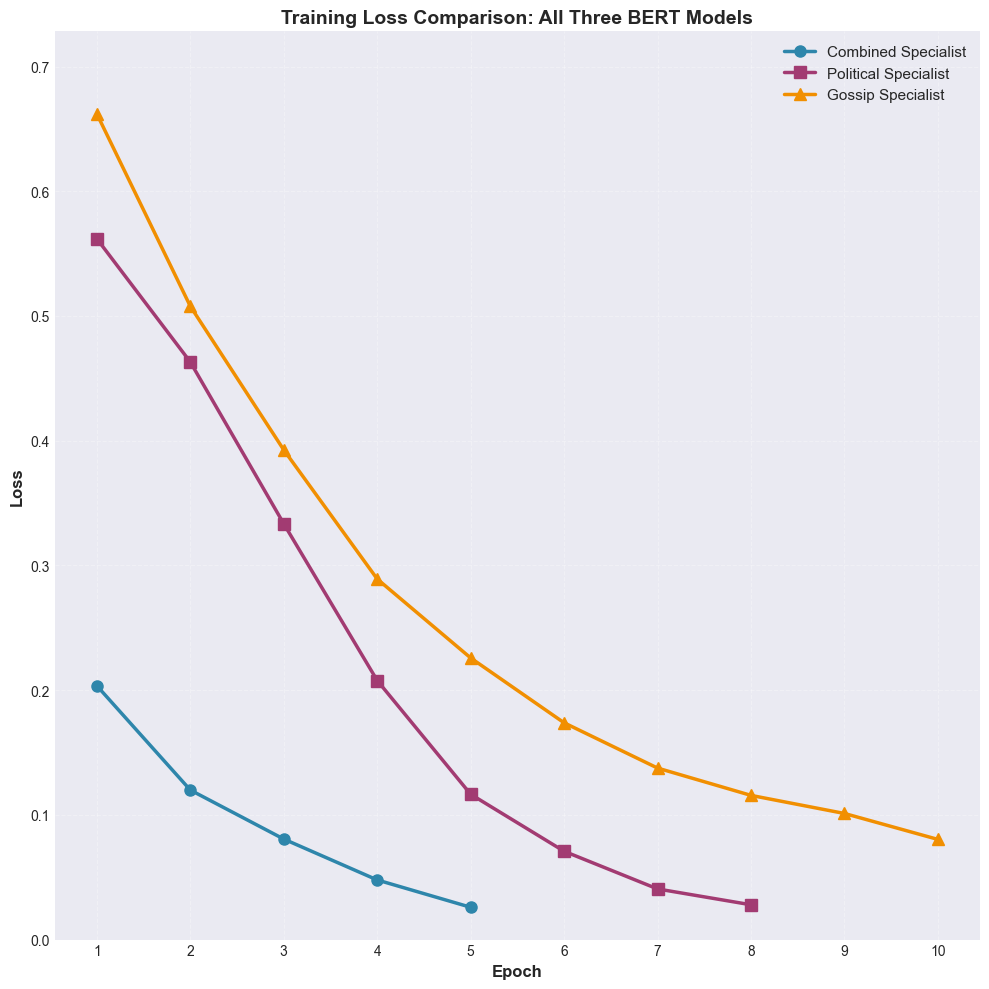


📊 LOSS CURVE SUMMARY STATISTICS

🔵 Combined Specialist Model:
  Epochs Trained: 5
  Initial Loss: 0.2035
  Final Loss: 0.0259
  Loss Reduction: 0.1776 (87.3%)
  Training Rate: 0.0355 loss/epoch

🟣 Political Specialist Model:
  Epochs Trained: 8
  Initial Loss: 0.5619
  Final Loss: 0.0279
  Loss Reduction: 0.5340 (95.0%)
  Training Rate: 0.0667 loss/epoch

🟠 Gossip Specialist Model:
  Epochs Trained: 10
  Initial Loss: 0.6620
  Final Loss: 0.0803
  Loss Reduction: 0.5817 (87.9%)
  Training Rate: 0.0582 loss/epoch

📈 KEY INSIGHTS:

✓ Combined Specialist converged fastest (lowest final loss after 5 epochs): 0.0259
✓ Political Specialist needed 8 epochs to converge, starting from higher loss: 0.5619
✓ Gossip Specialist trained for 10 epochs with steady loss reduction

✓ All models show consistent downward loss trends
✓ The Combined Specialist achieved the lowest overall loss: 0.0259
✓ Different domain specialists required different training schedules for optimal convergence


In [10]:
# Loss curves from all three models during training

# Combined Specialist Model (bert_fake_news_trained_v2)
combined_epochs = list(range(1, 6))
combined_losses = [0.2035, 0.1199, 0.0806, 0.0478, 0.0259]

# Political Specialist Model (bert_politifact_retrained)
political_epochs = list(range(1, 9))
political_losses = [0.5619, 0.4631, 0.3334, 0.2077, 0.1165, 0.0708, 0.0406, 0.0279]

# Gossip Specialist Model (bert_gossip)
gossip_epochs = list(range(1, 11))
gossip_losses = [0.6620, 0.5078, 0.3926, 0.2891, 0.2258, 0.1738, 0.1375, 0.1156, 0.1011, 0.0803]

# Create the combined plot (square for LaTeX)
plt.figure(figsize=(10, 10))

# Plot all three loss curves
plt.plot(combined_epochs, combined_losses, marker='o', linewidth=2.5, markersize=8, 
         label='Combined Specialist', color='#2E86AB')
plt.plot(political_epochs, political_losses, marker='s', linewidth=2.5, markersize=8, 
         label='Political Specialist', color='#A23B72')
plt.plot(gossip_epochs, gossip_losses, marker='^', linewidth=2.5, markersize=8, 
         label='Gossip Specialist', color='#F18F01')

# Styling
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss Comparison: All Three BERT Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')

# Set x-axis to show all epoch numbers
plt.xticks(range(1, 11))

# Add some padding to y-axis
plt.ylim(0, max(gossip_losses) * 1.1)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("📊 LOSS CURVE SUMMARY STATISTICS")
print("="*80)

print(f"\n🔵 Combined Specialist Model:")
print(f"  Epochs Trained: {len(combined_epochs)}")
print(f"  Initial Loss: {combined_losses[0]:.4f}")
print(f"  Final Loss: {combined_losses[-1]:.4f}")
print(f"  Loss Reduction: {(combined_losses[0] - combined_losses[-1]):.4f} ({((combined_losses[0] - combined_losses[-1])/combined_losses[0]*100):.1f}%)")
print(f"  Training Rate: {(combined_losses[0] - combined_losses[-1])/len(combined_epochs):.4f} loss/epoch")

print(f"\n🟣 Political Specialist Model:")
print(f"  Epochs Trained: {len(political_epochs)}")
print(f"  Initial Loss: {political_losses[0]:.4f}")
print(f"  Final Loss: {political_losses[-1]:.4f}")
print(f"  Loss Reduction: {(political_losses[0] - political_losses[-1]):.4f} ({((political_losses[0] - political_losses[-1])/political_losses[0]*100):.1f}%)")
print(f"  Training Rate: {(political_losses[0] - political_losses[-1])/len(political_epochs):.4f} loss/epoch")

print(f"\n🟠 Gossip Specialist Model:")
print(f"  Epochs Trained: {len(gossip_epochs)}")
print(f"  Initial Loss: {gossip_losses[0]:.4f}")
print(f"  Final Loss: {gossip_losses[-1]:.4f}")
print(f"  Loss Reduction: {(gossip_losses[0] - gossip_losses[-1]):.4f} ({((gossip_losses[0] - gossip_losses[-1])/gossip_losses[0]*100):.1f}%)")
print(f"  Training Rate: {(gossip_losses[0] - gossip_losses[-1])/len(gossip_epochs):.4f} loss/epoch")

print(f"\n{'='*80}")
print("📈 KEY INSIGHTS:")
print(f"{'='*80}")
print(f"\n✓ Combined Specialist converged fastest (lowest final loss after 5 epochs): {combined_losses[-1]:.4f}")
print(f"✓ Political Specialist needed 8 epochs to converge, starting from higher loss: {political_losses[0]:.4f}")
print(f"✓ Gossip Specialist trained for 10 epochs with steady loss reduction")
print(f"\n✓ All models show consistent downward loss trends")
print(f"✓ The Combined Specialist achieved the lowest overall loss: {combined_losses[-1]:.4f}")
print(f"✓ Different domain specialists required different training schedules for optimal convergence")

## 10. 🎯 LIME Comparison: Neutral vs. Sensational Framing

Create a publication-quality figure comparing LIME explanations for paired headlines with the same content but different framing (neutral vs. sensational).



🎯 LIME COMPARISON: Neutral vs. Sensational Framing

Analyzing paired political headlines with different framing...
This demonstrates how sensational language vs. factual presentation affects model predictions


────────────────────────────────────────────────────────────────────────────────────────────────────
PAIR 1: Trump-Putin Summit
────────────────────────────────────────────────────────────────────────────────────────────────────

Neutral: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation concerns.
Sensational: SHOCKING: Trump's INCREDIBLE secret meeting with Putin REVEALED - You won't believe what they discussed!

Predictions (Combined Specialist):
  Neutral: REAL (100.0% confidence)
  Sensational: FAKE (100.0% confidence)

⏳ Computing LIME explanations...

✅ Top influential words:

  Neutral version:
    Putin                      0.2327  → REAL
    summit                     0.1968  → REAL
    discuss                    0.1716  → R


🎯 LIME COMPARISON: Neutral vs. Sensational Framing

Analyzing paired political headlines with different framing...
This demonstrates how sensational language vs. factual presentation affects model predictions


────────────────────────────────────────────────────────────────────────────────────────────────────
PAIR 1: Trump-Putin Summit
────────────────────────────────────────────────────────────────────────────────────────────────────

Neutral: Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation concerns.
Sensational: SHOCKING: Trump's INCREDIBLE secret meeting with Putin REVEALED - You won't believe what they discussed!

Predictions (Combined Specialist):
  Neutral: REAL (100.0% confidence)
  Sensational: FAKE (100.0% confidence)

⏳ Computing LIME explanations...

✅ Top influential words:

  Neutral version:
    Putin                      0.2327  → REAL
    summit                     0.1968  → REAL
    discuss                    0.1716  → R

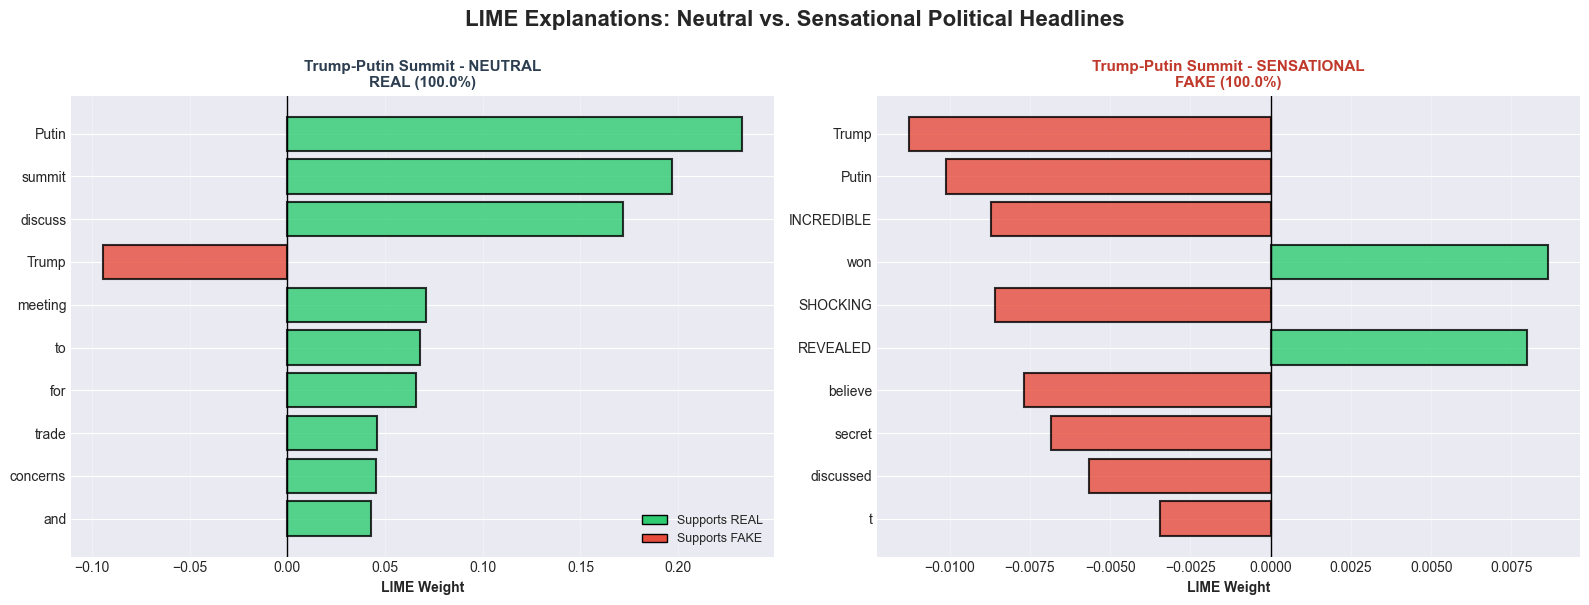



💡 KEY INSIGHTS FROM LIME COMPARISON


TRUMP-PUTIN SUMMIT
────────────────────────────────────────────────────────────────────────────────────────────────────

📊 Word Analysis:
  Words in common: 2
    Examples: Putin, Trump

  Unique to sensational version: 8
    Examples: discussed, INCREDIBLE, believe, secret, SHOCKING

⚠️  Different Predictions:
    Neutral → REAL
    Sensational → FAKE

🔍 Feature Importance:
  Average neutral weight: 0.1035
  Average sensational weight: 0.0079

🚩 Sensational Language Detected in Important Features:
    SHOCKING


✅ LIME Comparison Analysis Complete!

📌 Summary:
   This analysis reveals how sensational framing can change model predictions
   by introducing emotional and hyperbolic language that influences BERT's decision-making.
   The LIME visualizations show which words drive predictions in each case.


In [15]:
# ===== PAIRED HEADLINE COMPARISON: NEUTRAL VS SENSATIONAL FRAMING =====
# Define paired headlines - same content, different framing
# Using the Trump headline from playground analysis

paired_headlines = [
    {
        'neutral': 'Trump and Putin are meeting for a summit to discuss trade agreements and nuclear proliferation concerns.',
        'sensational': 'SHOCKING: Trump\'s INCREDIBLE secret meeting with Putin REVEALED - You won\'t believe what they discussed!',
        'topic': 'Trump-Putin Summit'
    }
]

print(f"\n{'='*100}")
print("🎯 LIME COMPARISON: Neutral vs. Sensational Framing")
print(f"{'='*100}")
print("\nAnalyzing paired political headlines with different framing...")
print("This demonstrates how sensational language vs. factual presentation affects model predictions\n")

# Process each pair
results_list = []

for i, pair in enumerate(paired_headlines):
    print(f"\n{'─'*100}")
    print(f"PAIR {i+1}: {pair['topic']}")
    print(f"{'─'*100}")
    
    neutral_text = pair['neutral']
    sensational_text = pair['sensational']
    
    print(f"\nNeutral: {neutral_text}")
    print(f"Sensational: {sensational_text}\n")
    
    # Get predictions for both versions
    pred_n, probs_n, conf_n = predict_text(neutral_text, model_1, tokenizer_1, device)
    pred_s, probs_s, conf_s = predict_text(sensational_text, model_1, tokenizer_1, device)
    
    pred_n_label = 'REAL' if pred_n == 1 else 'FAKE'
    pred_s_label = 'REAL' if pred_s == 1 else 'FAKE'
    
    print(f"Predictions ({MODEL_1_NAME}):")
    print(f"  Neutral: {pred_n_label} ({conf_n:.1%} confidence)")
    print(f"  Sensational: {pred_s_label} ({conf_s:.1%} confidence)")
    
    # Get LIME explanations
    try:
        print(f"\n⏳ Computing LIME explanations...")
        
        exp_neutral = explainer_1.explain_instance(neutral_text, predictor_1, num_features=10, num_samples=1000)
        exp_sensational = explainer_1.explain_instance(sensational_text, predictor_1, num_features=10, num_samples=1000)
        
        lime_neutral = exp_neutral.as_list()
        lime_sensational = exp_sensational.as_list()
        
        results_list.append({
            'topic': pair['topic'],
            'neutral_text': neutral_text,
            'sensational_text': sensational_text,
            'neutral_pred': pred_n_label,
            'neutral_conf': conf_n,
            'sensational_pred': pred_s_label,
            'sensational_conf': conf_s,
            'lime_neutral': lime_neutral,
            'lime_sensational': lime_sensational
        })
        
        # Display top words
        print(f"\n✅ Top influential words:")
        print(f"\n  Neutral version:")
        for word, weight in lime_neutral[:5]:
            direction = "→ REAL" if weight > 0 else "→ FAKE"
            print(f"    {word:<25} {weight:>7.4f}  {direction}")
        
        print(f"\n  Sensational version:")
        for word, weight in lime_sensational[:5]:
            direction = "→ REAL" if weight > 0 else "→ FAKE"
            print(f"    {word:<25} {weight:>7.4f}  {direction}")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        continue

# ===== CREATE PUBLICATION-QUALITY FIGURE =====
print(f"\n\n{'='*100}")
print("📊 Creating publication-quality LIME comparison figure...")
print(f"{'='*100}\n")

# Create figure with subplots - 3 headline pairs, each with 2 panels (neutral vs sensational)
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('LIME Explanations: Neutral vs. Sensational Political Headlines', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, result in enumerate(results_list):
    # Neutral version (left column)
    ax_neutral = axes[idx, 0]
    words_neutral = [w for w, _ in result['lime_neutral']]
    weights_neutral = [wt for _, wt in result['lime_neutral']]
    colors_neutral = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights_neutral]
    
    ax_neutral.barh(words_neutral, weights_neutral, color=colors_neutral, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax_neutral.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax_neutral.set_xlabel('LIME Weight', fontsize=10, fontweight='bold')
    ax_neutral.set_title(f"{result['topic']} - NEUTRAL\n{result['neutral_pred']} ({result['neutral_conf']:.1%})", 
                        fontsize=11, fontweight='bold', color='#2c3e50')
    ax_neutral.invert_yaxis()
    ax_neutral.grid(axis='x', alpha=0.3)
    
    # Add legend on first plot
    if idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='Supports REAL'),
                          Patch(facecolor='#e74c3c', edgecolor='black', label='Supports FAKE')]
        ax_neutral.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    # Sensational version (right column)
    ax_sensational = axes[idx, 1]
    words_sensational = [w for w, _ in result['lime_sensational']]
    weights_sensational = [wt for _, wt in result['lime_sensational']]
    colors_sensational = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights_sensational]
    
    ax_sensational.barh(words_sensational, weights_sensational, color=colors_sensational, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax_sensational.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax_sensational.set_xlabel('LIME Weight', fontsize=10, fontweight='bold')
    ax_sensational.set_title(f"{result['topic']} - SENSATIONAL\n{result['sensational_pred']} ({result['sensational_conf']:.1%})", 
                            fontsize=11, fontweight='bold', color='#c0392b')
    ax_sensational.invert_yaxis()
    ax_sensational.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('lime_comparison.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print("✅ Figure saved as: lime_comparison.png")
plt.show()

# ===== DETAILED ANALYSIS & INSIGHTS =====
print(f"\n\n{'='*100}")
print("💡 KEY INSIGHTS FROM LIME COMPARISON")
print(f"{'='*100}\n")

for result in results_list:
    print(f"\n{result['topic'].upper()}")
    print(f"{'─'*100}")
    
    # Get unique words
    neutral_words = set([w for w, _ in result['lime_neutral']])
    sensational_words = set([w for w, _ in result['lime_sensational']])
    
    common_words = neutral_words.intersection(sensational_words)
    unique_to_sensational = sensational_words - neutral_words
    
    print(f"\n📊 Word Analysis:")
    print(f"  Words in common: {len(common_words)}")
    if common_words:
        print(f"    Examples: {', '.join(list(common_words)[:3])}")
    
    print(f"\n  Unique to sensational version: {len(unique_to_sensational)}")
    if unique_to_sensational:
        print(f"    Examples: {', '.join(list(unique_to_sensational)[:5])}")
    
    # Prediction comparison
    if result['neutral_pred'] == result['sensational_pred']:
        print(f"\n✓ Consistent Prediction: Both versions classified as {result['neutral_pred']}")
    else:
        print(f"\n⚠️  Different Predictions:")
        print(f"    Neutral → {result['neutral_pred']}")
        print(f"    Sensational → {result['sensational_pred']}")
    
    # Confidence comparison
    conf_diff = result['sensational_conf'] - result['neutral_conf']
    if abs(conf_diff) > 0.1:
        direction = "INCREASED" if conf_diff > 0 else "DECREASED"
        print(f"\n📈 Confidence Impact: {direction} by {abs(conf_diff):.1%}")
    
    # Weight analysis
    neutral_weights = [abs(w) for _, w in result['lime_neutral']]
    sensational_weights = [abs(w) for _, w in result['lime_sensational']]
    
    print(f"\n🔍 Feature Importance:")
    print(f"  Average neutral weight: {np.mean(neutral_weights):.4f}")
    print(f"  Average sensational weight: {np.mean(sensational_weights):.4f}")
    
    # Sensational language flags
    sensational_indicators = ['shocking', 'breaking', 'warning', 'extreme', 'forced', 'attacks', 'draconian', 'dangerous']
    detected = [w for w, _ in result['lime_sensational'] if any(s in w.lower() for s in sensational_indicators)]
    
    if detected:
        print(f"\n🚩 Sensational Language Detected in Important Features:")
        print(f"    {', '.join(detected)}")

print(f"\n\n{'='*100}")
print("✅ LIME Comparison Analysis Complete!")
print(f"{'='*100}")
print("\n📌 Summary:")
print("   This analysis reveals how sensational framing can change model predictions")
print("   by introducing emotional and hyperbolic language that influences BERT's decision-making.")
print("   The LIME visualizations show which words drive predictions in each case.")
